<a href="https://colab.research.google.com/github/Alfasmoideen/Pdf/blob/main/housepriceKmean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
        Suburb             Address  Rooms Type      Price Method SellerG  \
0  Abbotsford       68 Studley St      2    h        NaN     SS  Jellis   
1  Abbotsford        85 Turner St      2    h  1480000.0      S  Biggin   
2  Abbotsford     25 Bloomburg St      2    h  1035000.0      S  Biggin   
3  Abbotsford  18/659 Victoria St      3    u        NaN     VB  Rounds   
4  Abbotsford        5 Charles St      3    h  1465000.0     SP  Biggin   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/09/2016       2.5    3067.0  ...       1.0  1.0     126.0           NaN   
1  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
2  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
3  4/02/2016       2.5    3067.0  ...       2.0  1.0       0.0           NaN   
4  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   

   YearBuilt         CouncilArea Lattitude  Longtitud

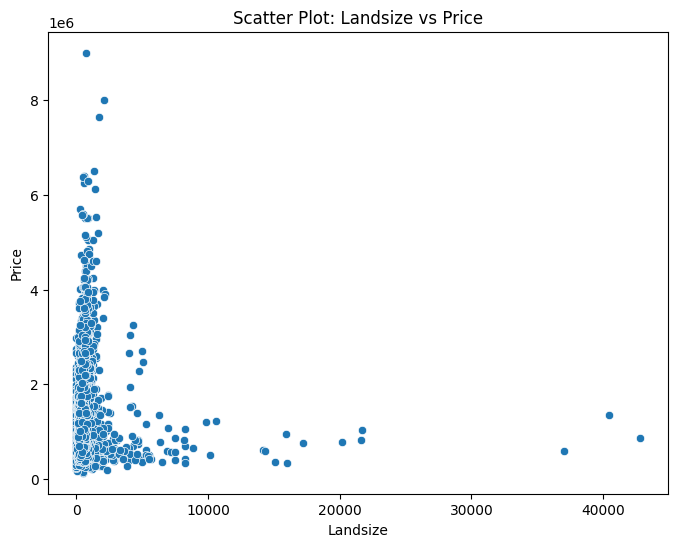

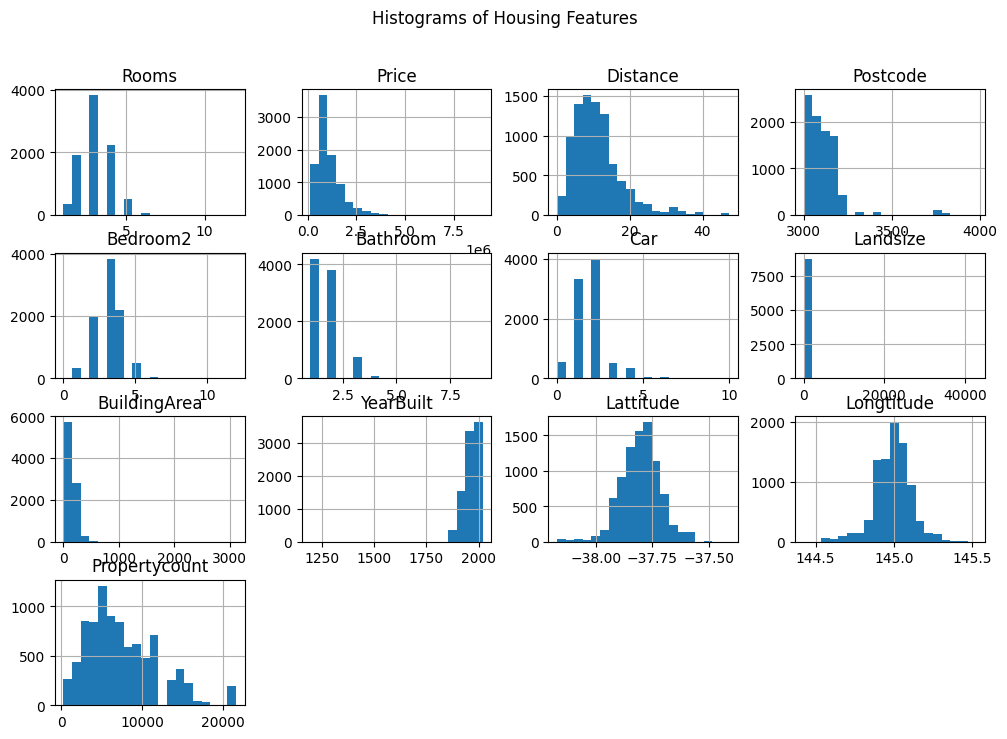

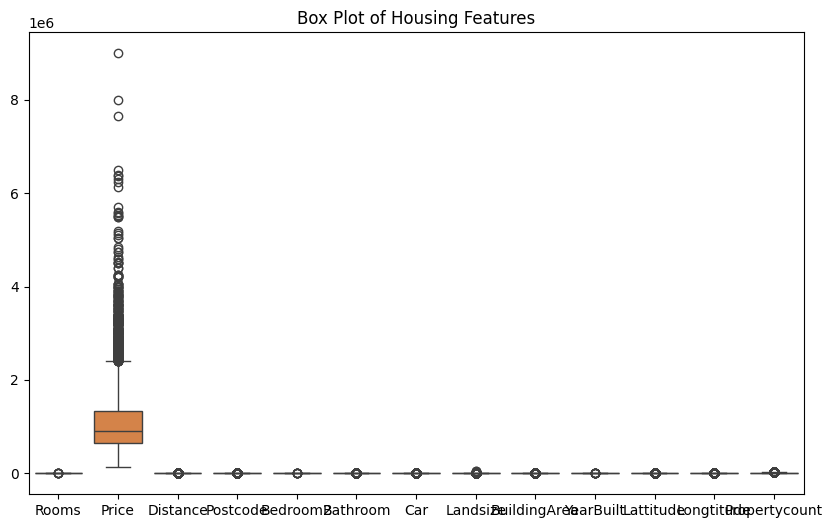

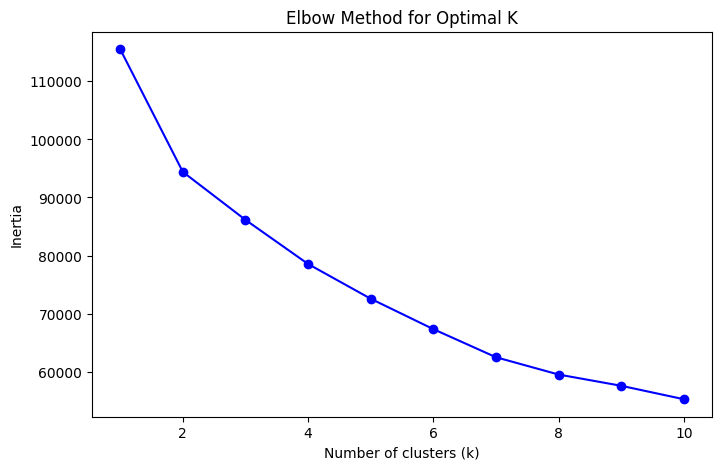


Cluster counts:
 Cluster
2    3665
1    2674
0    2548
Name: count, dtype: int64


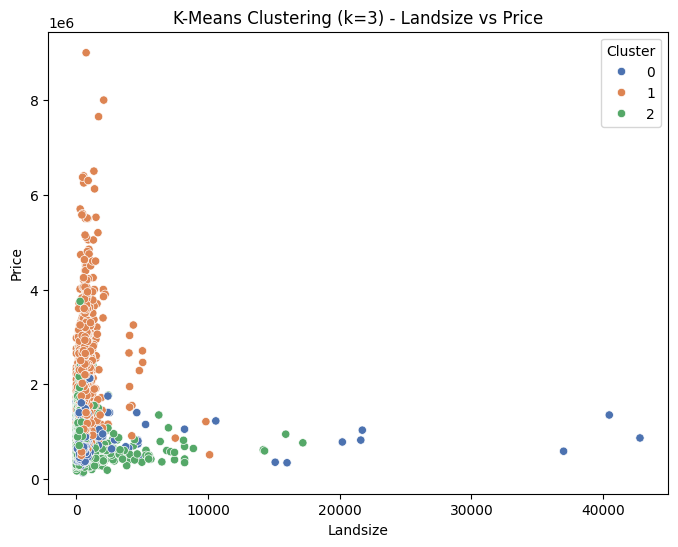


Clustered dataset saved as 'Housing_Price_Clustered.csv'


In [4]:
# ========================================
# K-Means Clustering on Housing_Price.csv (Fixed)
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================
# (a) EXPLORATORY DATA ANALYSIS
# ============================

data = pd.read_csv("/content/Melbourne_housing_FULL.csv")

print("First 5 rows:\n", data.head())
print("\nInfo:\n", data.info())
print("\nStatistical Summary:\n", data.describe())
print("\nMissing Values per Column:\n", data.isnull().sum())

# Drop rows with NaN values across the whole dataset to keep alignment
data = data.dropna()

# Extract numeric columns
numeric_data = data.select_dtypes(include=[np.number])
print("\nNumeric Columns Used:\n", numeric_data.columns.tolist())

# ============================
# (b) VISUALIZATION
# ============================

# (i) Scatter Plot (example using available numeric features)
if 'Landsize' in data.columns and 'Price' in data.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x='Landsize', y='Price', data=data)
    plt.title("Scatter Plot: Landsize vs Price")
    plt.show()

# (ii) Histogram
numeric_data.hist(figsize=(12,8), bins=20)
plt.suptitle("Histograms of Housing Features")
plt.show()

# (iii) Box Plot
plt.figure(figsize=(10,6))
sns.boxplot(data=numeric_data)
plt.title("Box Plot of Housing Features")
plt.show()

# ============================
# (c) K-MEANS CLUSTERING
# ============================

# Standardize numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_data)

# Try K values for Elbow Method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Choose optimal K (from elbow)
optimal_k = 3

# Apply K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels back — now lengths match
data['Cluster'] = clusters

print("\nCluster counts:\n", data['Cluster'].value_counts())

# Visualize clusters (if applicable)
if 'Landsize' in data.columns and 'Price' in data.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x='Landsize', y='Price', hue='Cluster', data=data, palette='deep')
    plt.title(f"K-Means Clustering (k={optimal_k}) - Landsize vs Price")
    plt.show()

# Save results
data.to_csv("Housing_Price_Clustered.csv", index=False)
print("\nClustered dataset saved as 'Housing_Price_Clustered.csv'")
